<a href="https://colab.research.google.com/github/AnchalPandey29/Movie-Recommendation-System/blob/main/KNNRecomendationSystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("movies.csv")
df.head()
df.shape

(4350, 7)

In [3]:
df.isnull().sum()

,0
Film Name,0
Year,0
Duration,623
Ratings,0
Number of Rators,360
Summary,0
Votes,0


In [4]:
df.head()

,Film Name,Year,Duration,Ratings,Number of Rators,Summary,Votes
0,1. Animal,2023,3h 24m,7.3,(27K),A son's love for his father. Often away due to...,"26,740"
1,2. Tiger 3,2023,2h 34m,7.4,(42K),Tiger and Zoya are back - to save the country ...,"42,378"
2,3. Jawan,2023,2h 49mNot Rated,7.1,(78K),A high-octane action thriller which outlines t...,"78,258"
3,4. Starfish,2023,2h 1m,9.3,(15K),Beautiful journey through the depths of the un...,"15,422"
4,5. 12th Fail,2023,2h 27m,9.2,(9K),The real-life story of IPS Officer Manoj Kumar...,"9,031"


In [5]:
# df['Number of Rators'] = (
#     df['Number of Rators'].str.replace("\xa0(","",regex =False).str.replace(")","",regex=False)
# )
# df['Number of Rators'] = (
#     df['Number of Rators'].str.replace("(","",regex =False)
# )

# df['Number of Rators'] = (
#     df['Number of Rators'].str.replace("K","000",regex =False).astype(float).astype(int)
# )

# df['Number of Rators']=df['Number of Rators'].fillna("0")

In [6]:
df["Number of Rators"].unique()

array(['\xa0(27K)', '\xa0(42K)', '\xa0(78K)', '\xa0(15K)', '\xa0(9K)',
       '\xa0(3.6K)', '\xa0(5.7K)', '\xa0(14K)', '\xa0(422)', '\xa0(5.5K)',
       '\xa0(7.4K)', '\xa0(10K)', '\xa0(160K)', '\xa0(423K)', '\xa0(23K)',
       '\xa0(29K)', '\xa0(6.1K)', '\xa0(22K)', '\xa0(1.7K)', '\xa0(35K)',
       '\xa0(150K)', nan, '\xa0(11K)', '\xa0(39K)', '\xa0(657K)',
       '\xa0(38K)', '\xa0(1.6K)', '\xa0(5.4K)', '\xa0(247K)',
       '\xa0(204K)', '\xa0(2.6K)', '\xa0(213K)', '\xa0(33K)', '\xa0(412)',
       '\xa0(92K)', '\xa0(31K)', '\xa0(21K)', '\xa0(238K)', '\xa0(26K)',
       '\xa0(127K)', '\xa0(145K)', '\xa0(197K)', '\xa0(6.7K)',
       '\xa0(114K)', '\xa0(66K)', '\xa0(203K)', '\xa0(57K)', '\xa0(383)',
       '\xa0(583)', '\xa0(13K)', '\xa0(8.5K)', '\xa0(59K)', '\xa0(87K)',
       '\xa0(39)', '\xa0(84K)', '\xa0(100K)', '\xa0(51K)', '\xa0(96K)',
       '\xa0(40K)', '\xa0(52K)', '\xa0(48K)', '\xa0(64K)', '\xa0(6.2K)',
       '\xa0(177K)', '\xa0(9.5K)', '\xa0(56K)', '\xa0(46K)', '\xa0(110K)',

In [7]:
df['Duration'] = df['Duration'].fillna("-")

In [8]:
df['Duration'].unique()

array(['3h 24m', '2h 34m', '2h 49mNot Rated', '2h 1m', '2h 27m', '2h 30m',
       '2h 10m', '2h 14m', '2h 21m', '2h 41m', '2h 19m', '2h 15m',
       '3h 7mNot Rated', '2h 50mPG-13', '2h 27mNot Rated', '2h 48m',
       '1h 52m', '2h 36m', '2h 26mNot Rated', '2h 40m', '2h 19mTV-MA',
       '2h 48mNot Rated', '2h 7mPG', '2h 53mNot Rated', '1h 35m',
       '2h 37mTV-MA', '1h 58mPG-13', '1h 59m', '-', '2h 41mNot Rated',
       '2h 52m', '1h 31mR', '1h 50m', '1h 57mPG', '2h 31mNot Rated',
       '2h 50mNot Rated', '3h 11mPG', '2h 12m', '2h 28m', '2h 15mTV-14',
       '2h 46mNot Rated', '2h 12mNot Rated', '2h 33mNot Rated',
       '2h 45mPG-13', '2h 18m', '2h 42mPG', '2h 20mNot Rated',
       '2h 43mNot Rated', '1h 44mNot Rated', '2h 25m', '2h 23m',
       '2h 19mNot Rated', '2h 2m', '2h 22m', '2h 35mTV-MA', '2h 2mPG',
       '2h 59mNot Rated', '2h 24mNot Rated', '2h 12mTV-MA', '2h 42mTV-14',
       '1h 50mTV-MA', '2h 35mNot Rated', '2h 39mNot Rated', '2h 5mR',
       '2h 21mNot Rated', '2h 3

In [9]:
df.isnull().sum()

,0
Film Name,0
Year,0
Duration,0
Ratings,0
Number of Rators,360
Summary,0
Votes,0


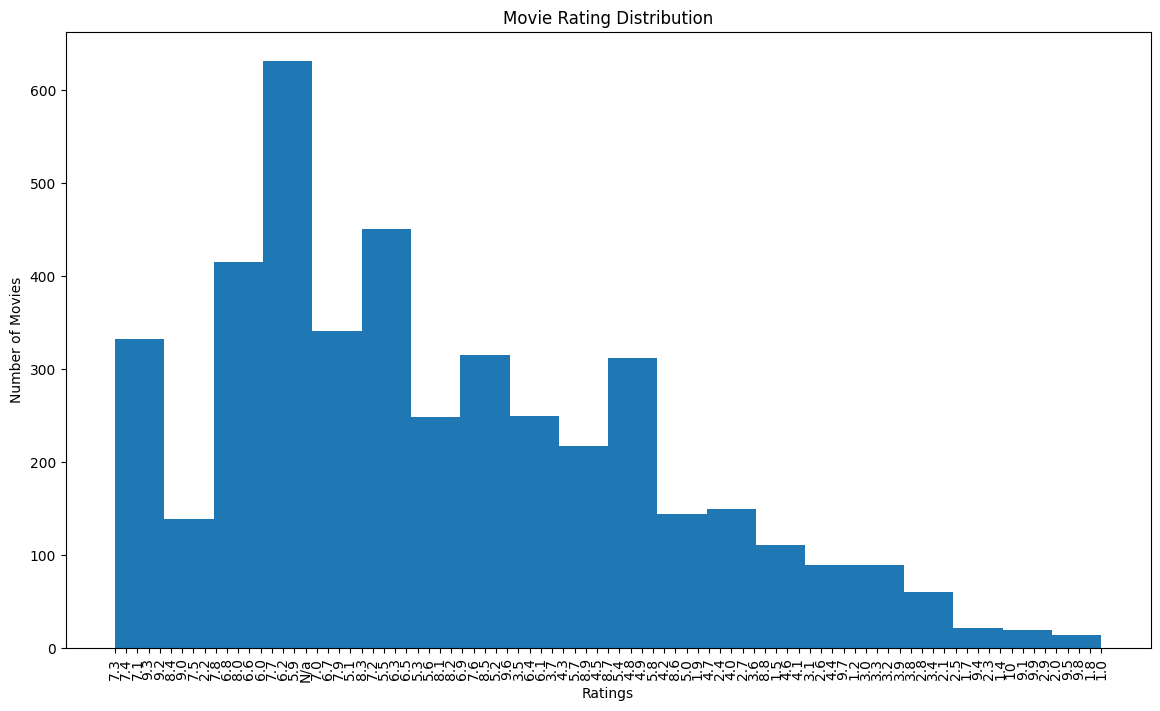

In [10]:
#Rating Distribution
plt.figure(figsize = (14,8))
plt.hist(df['Ratings'],bins=20)
plt.title("Movie Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Number of Movies")
plt.xticks(rotation =90)
plt.show()

In [11]:
df['Ratings']=df['Ratings'].str.replace("N/a","0")

In [12]:
#Top Rated Movies

top_movies = df.sort_values(by="Ratings",ascending=False).head(10)
top_movies

,Film Name,Year,Duration,Ratings,Number of Rators,Summary,Votes
3125,3126. Dear Latika,2023,1h 45m,9.9,(7),A girl who was destroyed by the people who lov...,7
3181,3182. Samanantar,2021,1h 30m,9.9,(8),In Hindi and Sanskrit language 'SAMANANTAR' me...,8
3425,3426. The Next Morning,2022,1h 49m,9.9,(33),"Children are similar to gods, so how do they b...",33
1088,1089. Juliet,2023,59m,9.9,(17),"Amidst dark comedy and unexpected plot twists,...",17
2552,2553. Romanticc Tukde,2023,1h 40m,9.8,(17),Around a protagonist who is hugely influenced ...,17
408,409. The Face of the Faceless,2023,2h 16m,9.7,(200),"Based on Sr. Rani Maria, this tale depicts the...",200
3189,3190. Oye Jassi Oye,2023,-,9.7,(73),N/a,73
1589,1590. The Rise of Sudarshan chakra,2023,2h 36m,9.7,(24),Film The Rise Of Sudarshan Chakra Is Based On ...,24
976,977. Pagalpan Next Level,2023,2h 8m,9.7,(236),Pagalpan Next Level is the biopic of fitness e...,236
2107,2108. Silsila Sidnaaz Ka,2021,1h 10m,9.6,(145),Will have unseen footage from the Bigg Boss ho...,145


In [13]:
#Top Voted Movies

top_movies = df.sort_values(by="Number of Rators",ascending=False).head(10)
top_movies

,Film Name,Year,Duration,Ratings,Number of Rators,Summary,Votes
1690,1691. Singh Is Bliing,2015,2h 21mNot Rated,5.0,(9K),A lazy youth failing to take up any responsibi...,"8,967"
619,620. Awara Paagal Deewana,2002,2h 38mNot Rated,6.2,(9K),A dentist's life turns into a roller coaster r...,"8,981"
4,5. 12th Fail,2023,2h 27m,9.2,(9K),The real-life story of IPS Officer Manoj Kumar...,"9,031"
1281,1282. Babli Bouncer,2022,1h 58m,6.6,(9K),"A one-of-a-kind story of a female bouncer, the...","9,022"
1086,1087. Sui Dhaaga: Made in India,2018,2h 2mNot Rated,6.8,(9K),It's a heart-warming story of pride and self-r...,"9,026"
697,698. Sandeep Aur Pinky Faraar,2021,2h 5m,6.3,(9K),"Sandeep, a bank executive and Pinky, a suspend...","8,982"
810,811. Khoobsurat,2014,2h 10mTV-14,6.4,(9K),A hopelessly romantic physiotherapist meets a ...,"9,001"
1066,1067. My Client's Wife,2020,1h 46m,6.2,(999),A defending lawyer uncovers the hideous truth ...,999
4172,4173. Shaadi No. 1,2005,2h 9mNot Rated,3.5,(997),Kothari has three daughters who shun the idea ...,997
1181,1182. Ankahi Kahaniya,2021,1h 50mTV-14,5.5,(995),"As big city life buzzes around them, lonely so...",995


In [14]:
df["Film Name"] = df['Film Name'].str.replace(r"[^a-zA-Z\s]","",regex = True)
df['Film Name']

,Film Name
0,Animal
1,Tiger
2,Jawan
3,Starfish
4,th Fail
...,...
4345,Black Market
4346,Bhookailas
4347,Palkon Ki Chhaon Mein
4348,Tikli and Laxmi Bomb


In [15]:
df = df.dropna(subset = ["Summary"])

In [16]:
df = df.reset_index(drop=True)

# NLP

In [17]:
#TEXT PREPROCESSING

# convert lowercase
df["Summary"] = df["Summary"].str.lower()

In [18]:
# remove extra spaces
df["Summary"] = df["Summary"].str.strip()

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

In [20]:
from sklearn.feature_extraction import text

stop_words = text.ENGLISH_STOP_WORDS
print(stop_words)
print(len(stop_words))
tfidf = TfidfVectorizer(stop_words="english")

tf_matrix = tfidf.fit_transform(df["Summary"])

frozenset({'via', 'wherever', 'why', 'around', 'same', 'call', 'toward', 'move', 'almost', 'him', 'more', 'their', 'per', 'you', 'beyond', 'cannot', 'were', 'three', 'became', 'thereupon', 'found', 'too', 'whence', 'as', 'how', 'beside', 'someone', 'be', 'after', 'if', 'part', 'whole', 'on', 'then', 'empty', 'forty', 'something', 'serious', 'behind', 'those', 'ours', 'hasnt', 'top', 'or', 'your', 'up', 'made', 'less', 'from', 'by', 'himself', 'third', 'hence', 'therefore', 'over', 'thereafter', 'could', 'my', 'they', 'anywhere', 'hers', 'for', 'above', 'full', 'within', 'nowhere', 'meanwhile', 'fire', 'everyone', 'neither', 'becomes', 'anyone', 'who', 'off', 'well', 'again', 'thick', 'latter', 'sometimes', 'what', 'it', 'twelve', 'us', 'between', 'should', 'namely', 'while', 'otherwise', 'other', 'bottom', 'often', 'which', 'formerly', 'among', 'this', 'already', 'de', 'under', 'an', 'hundred', 'own', 'these', 'ever', 'here', 'ltd', 'nobody', 'afterwards', 'in', 'fifty', 'un', 'nine', 

In [21]:
knn = NearestNeighbors(
    n_neighbors= 6,
    metric = "cosine",
    algorithm = "brute"
)

In [22]:
knn.fit(tf_matrix)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=6)

In [23]:
def recomendation(movie_name):
  movie_name = movie_name.lower()
  movie_list = df['Film Name'].str.lower().str.strip().values

  if movie_name not in movie_list:
    print("Movie not found in the dataset")

  index = df[df['Film Name'].str.lower().str.strip()==movie_name].index[0]
  distance, indice = knn.kneighbors(tf_matrix[index])
  print(indice)
  print("\nRecommended Movies\n")

  for i in range(1, len(indice[0])):
    movie_index = indice[0][i]

    name = df.iloc[movie_index]["Film Name"]
    rating = df.iloc[movie_index]["Ratings"]
    year = df.iloc[movie_index]["Year"]

    print(" Name",name," Rating",rating,"Year",year,)

In [24]:
recomendation("Animal")

[[   0 2909 2160  547 3023 2739]]

Recommended Movies

 Name  Baap Numbri Beta Dus Numbri  Rating 6.1 Year 1990
 Name  Shakti  Rating 7.6 Year 1982
 Name  Sab Moh Maaya Hai  Rating 9.0 Year 2023
 Name  Love Love Love  Rating 4.8 Year 1989
 Name  Kasam Paida Karne Wale Ki  Rating 5.7 Year 1984
